# LA Community Health Expansion Index — v2 (Objective Model)

## Executive Summary

This project identifies underserved Los Angeles ZIP codes for potential community health center expansion using public health, socioeconomic, and healthcare accessibility data.

**The analysis integrates:**
- ACS census indicators
- CDC PLACES health outcomes
- FQHC clinic accessibility data

**Two prioritization models were developed:**
1. Weighted Composite Index
2. Ridge Regression-based Health Need Index

**The final output includes:**
- ZIP code prioritization rankings
- healthcare desert analysis
- interactive Streamlit dashboard
- healthcare access visualizations

**What changed from v1:**  
- v1 used *subjective* domain weights (Need 45%, Demand 30%, Socioeconomic 25%) chosen manually.  
- v2 trains a **Ridge Regression** and **Random Forest** on a 3-year panel linking ACS socioeconomic  
variables to *actual PLACES health outcomes* — the resulting coefficients become the **data-driven weights**.

**Pipeline:**
1. Build PLACES panel (2020–2022 releases, 3 years × ~660 LA ZIPs)
2. Construct composite health outcome score Y per ZIP-year
3. Merge with paired ACS years (2017, 2018, 2019)
4. Train Ridge + Random Forest → extract data-driven weights
5. Score all 640 LA ZIPs using ACS 2021 + objective weights
6. Apply clinic density penalty → final Expansion Index v2

**Repository Data Sources:**

The analysis integrates:
- American Community Survey (ACS) socioeconomic indicators
- CDC PLACES chronic disease and preventive care indicators
- FQHC/community clinic accessibility data

## 0 | Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import json
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

try:
    import matplotlib.pyplot as plt
    PLOT = True
except ImportError:
    PLOT = False
    print("[INFO] matplotlib not found — skipping plots")

print("Imports OK ✓")

Imports OK ✓


## 1 | Configuration

In [9]:
# ── File paths ────────────────────────────────────────────────────────────────
ACS_PATH    = "ACS_2011_2021.csv"
V1_PATH     = "01_weighted_composite_index_model.csv"        # v1 results (for clinic density)
OUTPUT_PATH = "02__ridge_regression_health_index.csv"

PLACES_FILES = {
    # release_year : (csv_path, acs_year_to_pair)
    # Rule: ACS year <= BRFSS survey year (causal direction: X before Y)
    # 2020 release = 2017-2018 BRFSS  → pair ACS 2017
    # 2021 release = 2018-2019 BRFSS  → pair ACS 2018
    # 2022 release = 2019-2020 BRFSS  → pair ACS 2019
    2020: ("PLACES__Local_Data_for_Better_Health__ZCTA_Data_2020_release.csv", 2017),
    2021: ("PLACES__Local_Data_for_Better_Health__ZCTA_Data_2021_release.csv", 2018),
    2022: ("PLACES__Local_Data_for_Better_Health__ZCTA_Data_2022_release.csv", 2019),
}

# ── Geographic filter (LA County ZIP range) ───────────────────────────────────
LA_ZIP_MIN   = 90001
LA_ZIP_MAX   = 93099
MIN_POP      = 500          # exclude very small / uninhabited ZIPs
ACS_YEAR     = 2021         # most recent ACS year — used for final scoring
PENALTY_WEIGHT = 0.25       # how much existing clinic coverage reduces the score

# ── ACS predictor variables ───────────────────────────────────────────────────
ACS_PREDICTORS = [
    "poverty_rate",               # % below federal poverty line
    "unemployment_rate",          # % unemployed
    "median_household_income",    # median HH income — negative coef → inverted
    "edu_highschool_percent",     # HS graduation rate — negative coef → inverted
    "pop_hispanic",               # Hispanic population
    "pop_black",                  # Black population
    "population",                 # total population
    "median_age",                 # median age
    "age_dependency_ratio",       # elderly + child burden on working-age adults
    "mean_commute_time",          # avg commute (transportation barrier proxy)
    "percent_household_with_kids",# share of HH with children
    "household_size",             # average household size
]

# ── PLACES measures ────────────────────────────────────────────────────────────
# Disease / behavior burden — HIGH value = HIGH need
BURDEN_MEASURES = [
    "ACCESS2",    # uninsured rate (KEY: solves v1's biggest limitation)
    "DIABETES",   # diagnosed diabetes
    "BPHIGH",     # high blood pressure
    "CHD",        # coronary heart disease
    "COPD",       # chronic obstructive pulmonary disease
    "STROKE",     # stroke
    "KIDNEY",     # chronic kidney disease
    "MHLTH",      # mental health not good ≥14 days
    "PHLTH",      # physical health not good ≥14 days
    "OBESITY",    # obesity
    "LPA",        # physical inactivity
    "CSMOKING",   # current smoking
    "CASTHMA",    # current asthma
    "TEETHLOST",  # all teeth lost (oral health neglect proxy)
]

# Prevention utilization — HIGH value = GOOD (well-served) → will be INVERTED
PREVENTION_MEASURES = [
    "CHECKUP",       # annual checkup visit
    "DENTAL",        # dental visit
    "CERVICAL",      # cervical cancer screening
    "COLON_SCREEN",  # colorectal cancer screening
    "MAMMOUSE",      # mammography use
]

print("Configuration loaded ✓")

Configuration loaded ✓


## 2 | Build PLACES Panel
Load 3 release years, filter to LA County ZIPs, and pivot to wide format  
(one row per ZIP per release year, one column per health measure).

In [3]:
print("Building PLACES panel...")
panels = []

for release_yr, (path, acs_yr) in PLACES_FILES.items():
    df = pd.read_csv(path, low_memory=False)

    # Filter to LA County ZIPs and crude prevalence only
    df = df[(df["LocationName"] >= LA_ZIP_MIN) &
            (df["LocationName"] <= LA_ZIP_MAX) &
            (df["DataValueTypeID"] == "CrdPrv")].copy()

    # Pivot: one row per ZIP, columns = MeasureId values
    wide = df.pivot_table(
        index="LocationName", columns="MeasureId",
        values="Data_Value", aggfunc="mean"
    ).reset_index()
    wide.columns.name = None
    wide["release_year"] = release_yr
    wide["acs_year"]     = acs_yr
    wide = wide.rename(columns={"LocationName": "zip_code"})
    panels.append(wide)
    print(f"  {release_yr} release: {len(wide):,} LA ZIPs")

places_panel = pd.concat(panels, ignore_index=True)
places_panel["zip_code"] = places_panel["zip_code"].astype(int)

print(f"\nPanel shape: {places_panel.shape}")
print(f"Total ZIP-year observations: {len(places_panel):,}")
print(f"Release years: {sorted(places_panel['release_year'].unique())}")
places_panel.head(3)

Building PLACES panel...
  2020 release: 660 LA ZIPs
  2021 release: 660 LA ZIPs
  2022 release: 660 LA ZIPs

Panel shape: (1980, 33)
Total ZIP-year observations: 1,980
Release years: [np.int64(2020), np.int64(2021), np.int64(2022)]


,zip_code,ACCESS2,ARTHRITIS,BINGE,BPHIGH,BPMED,CANCER,CASTHMA,CERVICAL,CHD,...,MHLTH,OBESITY,PHLTH,SLEEP,STROKE,TEETHLOST,release_year,acs_year,DEPRESSION,GHLTH
0,90001,33.4,17.5,16.8,26.9,61.0,3.7,10.2,78.0,5.5,...,18.8,35.2,18.5,40.6,3.6,21.8,2020,2017,NaN,NaN
1,90002,30.7,18.7,16.2,28.9,63.9,3.9,11.0,78.3,5.6,...,19.5,36.2,18.8,42.2,4.0,25.0,2020,2017,NaN,NaN
2,90003,31.1,18.4,16.3,28.8,63.0,3.7,11.0,78.4,5.5,...,19.7,36.6,18.9,42.4,3.9,25.7,2020,2017,NaN,NaN


## 3 | Build Composite Health Outcome Score Y
Combine all PLACES measures into one health outcome score per ZIP-year.

- **Burden measures**: normalise to [0,1] — higher = worse health = more need  
- **Prevention measures**: normalise then **invert** (1 − x) — low utilisation = high need  
- Average all normalised indicators → `places_score` ∈ [0, 1]

This becomes the **dependent variable (Y)** in the regression model.

In [4]:
scaler = MinMaxScaler()
rows = []

for (zip_code, rel_yr), grp in places_panel.groupby(["zip_code", "release_year"]):
    row = {"zip_code": zip_code, "release_year": rel_yr,
           "acs_year": grp["acs_year"].iloc[0]}
    for m in BURDEN_MEASURES + PREVENTION_MEASURES:
        row[m] = grp[m].values[0] if m in grp.columns else np.nan
    rows.append(row)

places_df = pd.DataFrame(rows)

# Normalise burden measures (high = high need)
for m in BURDEN_MEASURES:
    vals = places_df[m].fillna(places_df[m].median()).values.reshape(-1, 1)
    places_df[f"{m}_n"] = scaler.fit_transform(vals).flatten()

# Normalise and invert prevention measures (low utilisation = high need)
for m in PREVENTION_MEASURES:
    vals = places_df[m].fillna(places_df[m].median()).values.reshape(-1, 1)
    places_df[f"{m}_n"] = 1 - scaler.fit_transform(vals).flatten()

# Equal-weight composite
norm_cols = [f"{m}_n" for m in BURDEN_MEASURES + PREVENTION_MEASURES]
places_df["places_score"] = places_df[norm_cols].mean(axis=1)

print("PLACES health outcome score stats:")
print(places_df["places_score"].describe().round(3))
print("\nTop 10 ZIPs by health burden (highest places_score):")
display(
    places_df.sort_values("places_score", ascending=False)
    [["zip_code", "release_year", "places_score", "ACCESS2", "DIABETES", "MHLTH", "LPA"]]
    .head(10)
    .reset_index(drop=True)
)

PLACES health outcome score stats:
count    1980.000
mean        0.324
std         0.095
min         0.138
25%         0.249
50%         0.318
75%         0.388
max         0.746
Name: places_score, dtype: float64

Top 10 ZIPs by health burden (highest places_score):


,zip_code,release_year,places_score,ACCESS2,DIABETES,MHLTH,LPA
0,90073,2022,0.745662,17.4,28.8,15.1,37.3
1,90073,2021,0.728867,20.5,29.5,16.8,42.0
2,90073,2020,0.728475,17.9,31.1,17.3,37.6
3,92233,2021,0.671700,38.4,16.6,23.1,47.3
4,92233,2022,0.671447,34.7,16.9,20.4,43.8
5,92283,2022,0.663270,19.9,19.9,20.7,37.6
6,92233,2020,0.662524,36.8,16.6,23.1,42.0
7,92401,2022,0.646539,29.2,17.1,20.6,39.8
8,92283,2021,0.645072,21.7,19.7,21.7,39.0
9,92401,2021,0.633894,31.6,16.7,21.4,43.9


## 4 | Load & Merge ACS Panel
Load ACS data for paired years (2017, 2018, 2019) and merge with PLACES panel.

**Causal alignment rule:** ACS year ≤ BRFSS survey year  
(socioeconomic conditions X must precede health outcomes Y in time)

In [5]:
print("Loading ACS data (filtered to LA, years 2017-2019)...")
ACS_YEARS = list(PLACES_FILES[yr][1] for yr in PLACES_FILES)  # [2017, 2018, 2019]

chunks = []
for chunk in pd.read_csv(ACS_PATH, chunksize=50000,
                          low_memory=False, dtype={"GEOID": int}):
    mask = ((chunk["GEOID"].values >= LA_ZIP_MIN) &
            (chunk["GEOID"].values <= LA_ZIP_MAX) &
            (chunk["year"].values <= max(ACS_YEARS)) &
            (chunk["year"].values >= min(ACS_YEARS)))
    sub = chunk.loc[mask].copy()
    if len(sub):
        avail = [c for c in ACS_PREDICTORS if c in sub.columns]
        keep  = list(dict.fromkeys(["GEOID", "year", "population"] + avail))
        chunks.append(sub[keep])

acs_panel = pd.concat(chunks, ignore_index=True)
acs_panel = acs_panel.rename(columns={"GEOID": "zip_code", "year": "acs_year"})
print(f"ACS panel: {len(acs_panel):,} rows | years: {sorted(acs_panel['acs_year'].unique())}")

# Merge PLACES + ACS
merged = places_df.merge(acs_panel, on=["zip_code", "acs_year"], how="inner")
merged = merged[merged["population"].fillna(0) >= MIN_POP].copy()

X_COLS = list(dict.fromkeys([c for c in ACS_PREDICTORS if c in merged.columns]))
for c in X_COLS:
    merged[c] = merged[c].fillna(merged[c].median())
merged = merged.dropna(subset=["places_score"]).reset_index(drop=True)
del acs_panel, chunks; gc.collect()

print(f"\nMerged panel: {len(merged):,} ZIP-year obs | {merged['zip_code'].nunique()} unique ZIPs")
print(f"ACS predictors used: {X_COLS}")

Loading ACS data (filtered to LA, years 2017-2019)...
ACS panel: 2,028 rows | years: [np.int64(2017), np.int64(2018), np.int64(2019)]

Merged panel: 1,905 ZIP-year obs | 637 unique ZIPs
ACS predictors used: ['poverty_rate', 'unemployment_rate', 'median_household_income', 'edu_highschool_percent', 'pop_hispanic', 'pop_black', 'population', 'median_age', 'age_dependency_ratio', 'mean_commute_time', 'percent_household_with_kids', 'household_size']


## 5 | Model Training — ACS → PLACES Health Outcomes
Train two models to extract **objective weights**:

- **Ridge Regression** (linear, interpretable coefficients → become index weights)  
- **Random Forest** (non-linear validation, feature importance cross-check)

Both use 5-fold cross-validation. R² > 0.80 confirms ACS variables are strong predictors of health outcomes.

In [6]:
# Normalize predictors
scaler_X = MinMaxScaler()
X_norm = scaler_X.fit_transform(merged[X_COLS].values.astype(float))
y      = merged["places_score"].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Ridge Regression ──────────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
cv_ridge = cross_val_score(ridge, X_norm, y, cv=kf, scoring="r2")
ridge.fit(X_norm, y)

ridge_coefs = pd.DataFrame({
    "variable":    X_COLS,
    "coefficient": ridge.coef_,
    "abs_coef":    np.abs(ridge.coef_),
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print(f"Ridge Regression  CV R² = {cv_ridge.mean():.3f} ± {cv_ridge.std():.3f}")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                            random_state=42, n_jobs=-1)
cv_rf = cross_val_score(rf, X_norm, y, cv=kf, scoring="r2")
rf.fit(X_norm, y)

rf_importance = pd.DataFrame({
    "variable":   X_COLS,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"Random Forest     CV R² = {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

print("\n── Ridge Coefficients (objective weights) ───────────────────────────")
display(ridge_coefs[["variable", "coefficient"]])

print("\n── Random Forest Feature Importance (validation) ────────────────────")
display(rf_importance)

Ridge Regression  CV R² = 0.820 ± 0.007
Random Forest     CV R² = 0.843 ± 0.016

── Ridge Coefficients (objective weights) ───────────────────────────


,variable,coefficient
0,median_household_income,-0.199629
1,unemployment_rate,0.159728
2,poverty_rate,0.159087
3,edu_highschool_percent,-0.149677
4,age_dependency_ratio,0.145613
5,median_age,0.088195
6,household_size,0.081386
7,population,-0.072700
8,pop_hispanic,0.059488
9,percent_household_with_kids,0.045421



── Random Forest Feature Importance (validation) ────────────────────


,variable,importance
0,median_household_income,0.544130
1,edu_highschool_percent,0.241169
2,poverty_rate,0.116541
3,age_dependency_ratio,0.043309
4,unemployment_rate,0.013050
5,median_age,0.011544
6,mean_commute_time,0.008419
7,percent_household_with_kids,0.006890
8,population,0.005809
9,pop_black,0.003440


## 6 | Build Objective Expansion Index v2
Apply Ridge coefficients as objective weights to ACS 2021 data (most recent year).

**Logic:**
- Positive coefficient → higher ACS value = more need → keep as-is  
- Negative coefficient → higher ACS value = less need → invert: (1 − normalised value) × |coef|

In [7]:
print("Loading ACS 2021 for final scoring...")
chunks = []
for chunk in pd.read_csv(ACS_PATH, chunksize=50000,
                          low_memory=False, dtype={"GEOID": int}):
    mask = ((chunk["GEOID"].values >= LA_ZIP_MIN) &
            (chunk["GEOID"].values <= LA_ZIP_MAX) &
            (chunk["year"].values == ACS_YEAR))
    sub = chunk.loc[mask].copy()
    if len(sub):
        avail = list(dict.fromkeys(["GEOID", "population"] +
                                    [c for c in X_COLS if c in sub.columns]))
        chunks.append(sub[avail])

acs_2021 = pd.concat(chunks, ignore_index=True)
acs_2021 = (acs_2021[acs_2021["population"].fillna(0) >= MIN_POP]
             .drop_duplicates("GEOID")
             .reset_index(drop=True))
for c in X_COLS:
    if c in acs_2021.columns:
        acs_2021[c] = acs_2021[c].fillna(acs_2021[c].median())

print(f"ACS 2021: {len(acs_2021):,} ZIP codes")

# Normalise
avail_X = [c for c in X_COLS if c in acs_2021.columns]
X_s = MinMaxScaler().fit_transform(acs_2021[avail_X].values.astype(float))

# Apply Ridge weights
coef_dict = dict(zip(ridge_coefs["variable"], ridge_coefs["coefficient"]))
weighted  = np.zeros(len(acs_2021))
for i, col in enumerate(avail_X):
    coef = coef_dict.get(col, 0.0)
    vals = X_s[:, i]
    weighted += vals * coef if coef >= 0 else (1 - vals) * abs(coef)

need_score = (weighted - weighted.min()) / (weighted.max() - weighted.min())

result = pd.DataFrame({
    "zip_code":             acs_2021["GEOID"].values,
    "population":           acs_2021["population"].values,
    "objective_need_score": need_score,
})
print("Objective need score computed ✓")

Loading ACS 2021 for final scoring...
ACS 2021: 640 ZIP codes
Objective need score computed ✓


## 7 | Apply Clinic Density Penalty & Final Ranking
Import clinic density from v1 results and apply the same penalty:

`expansion_index_v2 = clip(objective_need_score − 0.25 × clinic_density, 0, ∞)`  
Then re-normalise to [0, 1] and rank.

In [10]:
# Load v1 for clinic density
v1 = pd.read_csv(V1_PATH)
result = result.merge(
    v1[["zip_code", "clinic_density", "nearby_clinic_count",
        "poverty_rate", "median_household_income", "expansion_index"]],
    on="zip_code", how="left"
)
result["clinic_density"]      = result["clinic_density"].fillna(0)
result["nearby_clinic_count"] = result["nearby_clinic_count"].fillna(0)

# Apply penalty and normalise
raw_pen = (result["objective_need_score"] - PENALTY_WEIGHT * result["clinic_density"]).clip(lower=0)
result["expansion_index_v2"] = (raw_pen - raw_pen.min()) / (raw_pen.max() - raw_pen.min())

# Sort and rank
result = result.sort_values("expansion_index_v2", ascending=False).reset_index(drop=True)
result.insert(0, "rank_v2", range(1, len(result) + 1))

# Add v1 rank for comparison
v1_ranked = v1.sort_values("expansion_index", ascending=False).reset_index(drop=True)
v1_ranked["rank_v1"] = range(1, len(v1_ranked) + 1)
result = result.merge(v1_ranked[["zip_code", "rank_v1"]], on="zip_code", how="left")
result["rank_change"] = result["rank_v1"] - result["rank_v2"]   # positive = moved up

result.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(result):,} ranked ZIP codes → '{OUTPUT_PATH}' ✓")

Saved 640 ranked ZIP codes → '02__ridge_regression_health_index.csv' ✓


## 8 | Results — Top 15 & v1 vs v2 Comparison

In [11]:
display_cols = ["rank_v2", "zip_code", "expansion_index_v2",
               "objective_need_score", "population",
               "poverty_rate", "nearby_clinic_count",
               "expansion_index", "rank_v1", "rank_change"]

top15 = result[display_cols].head(15).copy()
top15 = top15.rename(columns={
    "rank_v2": "Rank v2", "zip_code": "ZIP",
    "expansion_index_v2": "Index v2", "objective_need_score": "Need Score",
    "population": "Population", "poverty_rate": "Poverty%",
    "nearby_clinic_count": "Clinics", "expansion_index": "Index v1",
    "rank_v1": "Rank v1", "rank_change": "Δ Rank"
})
top15["Index v2"]   = top15["Index v2"].map("{:.3f}".format)
top15["Need Score"] = top15["Need Score"].map("{:.3f}".format)
top15["Index v1"]   = top15["Index v1"].map("{:.3f}".format)
top15["Population"] = top15["Population"].map("{:,.0f}".format)
top15["Poverty%"]   = top15["Poverty%"].map("{:.1f}%".format)
top15["Δ Rank"]     = top15["Δ Rank"].map(lambda x: f"↑{int(x)}" if x > 0 else (f"↓{int(abs(x))}" if x < 0 else "─") if pd.notna(x) else "─")

display(top15.set_index("Rank v2").style.set_caption("Top 15 — Objective Expansion Index v2"))

# Overlap summary
v1_top10 = set(v1.sort_values("expansion_index", ascending=False).head(10)["zip_code"])
v2_top10 = set(result.head(10)["zip_code"])
print(f"\n── Top 10 Overlap ──────────────────────────────────────────────────")
print(f"  v1 (subjective):  {sorted(v1_top10)}")
print(f"  v2 (objective):   {sorted(v2_top10)}")
print(f"  In common  : {len(v1_top10 & v2_top10)}/10")
print(f"  New in v2  : {sorted(v2_top10 - v1_top10)}")
print(f"  Dropped    : {sorted(v1_top10 - v2_top10)}")

,ZIP,Index v2,Need Score,Population,Poverty%,Clinics,Index v1,Rank v1,Δ Rank
Rank v2,,,,,,,,,
1,92327,1.000,1.000,756,66.8%,0,0.890,10,↑9
2,92258,0.970,0.970,627,53.1%,0,1.000,1,↓1
3,92283,0.796,0.796,"1,918",46.8%,0,0.934,3,─
4,92281,0.791,0.891,"2,548",37.2%,2,0.928,5,↑1
5,90003,0.787,0.787,"75,190",26.5%,0,0.976,2,↓3
6,90073,0.783,0.933,881,56.1%,3,0.525,280,↑274
7,92274,0.780,0.780,"12,843",23.5%,0,0.768,54,↑47
8,92347,0.772,0.772,754,35.5%,0,0.855,12,↑4
9,90011,0.768,0.818,"109,511",27.3%,1,0.933,4,↓5



── Top 10 Overlap ──────────────────────────────────────────────────
  v1 (subjective):  [90002, 90003, 90011, 90044, 90059, 91963, 92258, 92281, 92283, 92327]
  v2 (objective):   [90003, 90011, 90058, 90073, 92258, 92274, 92281, 92283, 92327, 92347]
  In common  : 6/10
  New in v2  : [90058, 90073, 92274, 92347]
  Dropped    : [90002, 90044, 90059, 91963]


## 9 | Visualisation

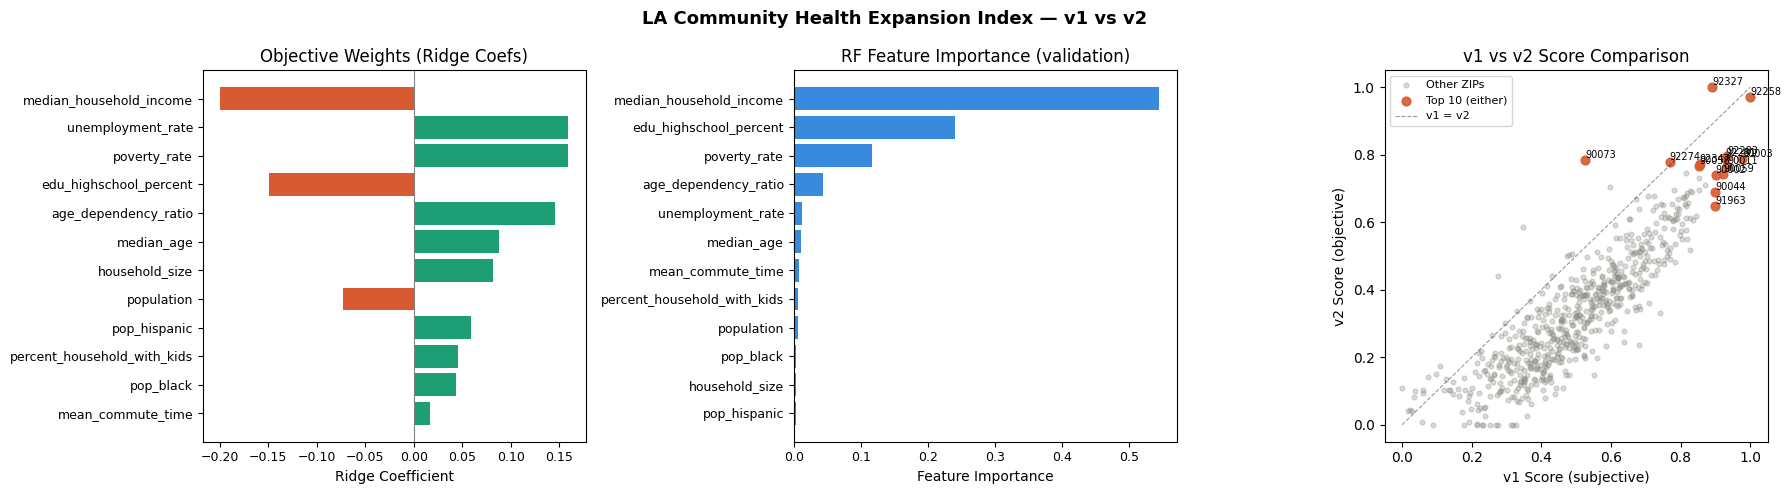

Saved → v1_vs_v2_comparison.png ✓


In [12]:
if not PLOT:
    print("Install matplotlib: pip install matplotlib")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("LA Community Health Expansion Index — v1 vs v2", fontsize=13, fontweight="bold")

    # ── Left: Ridge coefficients bar chart ────────────────────────────────────
    ax = axes[0]
    colors = ["#D85A30" if c < 0 else "#1D9E75" for c in ridge_coefs["coefficient"]]
    ax.barh(ridge_coefs["variable"][::-1], ridge_coefs["coefficient"][::-1], color=colors[::-1])
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("Ridge Coefficient")
    ax.set_title("Objective Weights (Ridge Coefs)")
    ax.tick_params(labelsize=9)

    # ── Middle: RF feature importance ─────────────────────────────────────────
    ax = axes[1]
    ax.barh(rf_importance["variable"][::-1], rf_importance["importance"][::-1], color="#378ADD")
    ax.set_xlabel("Feature Importance")
    ax.set_title("RF Feature Importance (validation)")
    ax.tick_params(labelsize=9)

    # ── Right: v1 vs v2 score scatter ─────────────────────────────────────────
    ax = axes[2]
    comp = result.dropna(subset=["expansion_index"])
    in_both = (comp["rank_v1"] <= 10) | (comp["rank_v2"] <= 10)
    ax.scatter(comp.loc[~in_both, "expansion_index"],
               comp.loc[~in_both, "expansion_index_v2"],
               alpha=0.3, s=12, color="#888780", label="Other ZIPs")
    ax.scatter(comp.loc[in_both, "expansion_index"],
               comp.loc[in_both, "expansion_index_v2"],
               alpha=0.9, s=40, color="#D85A30", label="Top 10 (either)")
    for _, row in comp[in_both].iterrows():
        ax.annotate(str(int(row["zip_code"])),
                    (row["expansion_index"], row["expansion_index_v2"]),
                    fontsize=7, ha="left", va="bottom")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4, label="v1 = v2")
    ax.set_xlabel("v1 Score (subjective)")
    ax.set_ylabel("v2 Score (objective)")
    ax.set_title("v1 vs v2 Score Comparison")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("v1_vs_v2_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → v1_vs_v2_comparison.png ✓")

## 10 | Sensitivity Analysis
Test stability of Top 10 rankings by varying the clinic density penalty weight  
(0.0 = no penalty, 0.25 = baseline, 0.50 = heavy penalty).

In [13]:
scenarios = {"No penalty": 0.0, "Baseline (0.25)": 0.25, "Heavy (0.50)": 0.50}
top10_sets = {}

for name, pw in scenarios.items():
    raw = (result["objective_need_score"] - pw * result["clinic_density"]).clip(lower=0)
    raw_norm = (raw - raw.min()) / (raw.max() - raw.min())
    top10_sets[name] = set(result.loc[raw_norm.nlargest(10).index, "zip_code"])

print("── Sensitivity: Top-10 Jaccard Similarity ──────────────────────────────")
names = list(top10_sets.keys())
for i, a in enumerate(names):
    for b in names[i+1:]:
        inter   = len(top10_sets[a] & top10_sets[b])
        union   = len(top10_sets[a] | top10_sets[b])
        jaccard = inter / union if union else 0
        print(f"  {a:22s} vs {b:22s} : {jaccard:.2f}  ({inter}/10 overlap)")

comparison = pd.DataFrame({k: sorted(v) for k, v in top10_sets.items()})
display(comparison)

── Sensitivity: Top-10 Jaccard Similarity ──────────────────────────────
  No penalty             vs Baseline (0.25)        : 0.54  (7/10 overlap)
  No penalty             vs Heavy (0.50)           : 0.33  (5/10 overlap)
  Baseline (0.25)        vs Heavy (0.50)           : 0.67  (8/10 overlap)


,No penalty,Baseline (0.25),Heavy (0.50)
0,90002,90003,90003
1,90003,90011,90011
2,90011,90058,90058
3,90073,90073,90059
4,92254,92258,92258
5,92257,92274,92274
6,92258,92281,92283
7,92281,92283,92327
8,92283,92327,92347
9,92327,92347,92356


## 11 | Score Distribution Summary

In [14]:
print("── Expansion Index v2 Distribution ─────────────────────────────────────")
print(result["expansion_index_v2"].describe().round(4).to_string())

result["decile"] = pd.qcut(result["expansion_index_v2"], 10, labels=False) + 1
decile_stats = result.groupby("decile").agg(
    count         = ("zip_code",           "count"),
    avg_index_v2  = ("expansion_index_v2", "mean"),
    avg_poverty   = ("poverty_rate",       "mean"),
    avg_pop       = ("population",         "mean"),
    avg_clinics   = ("nearby_clinic_count","mean"),
).round(2)
print("\n── Decile Breakdown (10 = highest priority) ─────────────────────────────")
display(decile_stats)

── Expansion Index v2 Distribution ─────────────────────────────────────
count    640.0000
mean       0.3298
std        0.1792
min        0.0000
25%        0.1920
50%        0.3192
75%        0.4395
max        1.0000

── Decile Breakdown (10 = highest priority) ─────────────────────────────


,count,avg_index_v2,avg_poverty,avg_pop,avg_clinics
decile,,,,,
1,64,0.06,5.76,25240.03,1.25
2,64,0.14,7.02,35345.05,0.70
3,64,0.19,7.59,28270.66,0.69
4,64,0.24,7.60,31991.64,0.39
5,64,0.29,10.67,30074.05,0.58
6,64,0.34,12.09,37466.92,0.55
7,64,0.39,12.93,34497.84,0.47
8,64,0.44,14.90,43649.53,0.52
9,64,0.52,18.40,37595.09,0.30


## Business Impact

This framework provides a reproducible, data-driven approach for identifying underserved communities and prioritizing healthcare expansion planning across Los Angeles County.

Potential applications include:
- FQHC expansion planning
- healthcare resource allocation
- preventive care targeting
- healthcare accessibility analysis
- public health planning